# Exploratory Data Analysis for Text and Vote Label
This notebook performs EDA on the `fetched_data.json` dataset, focusing on text and vote label analysis. Tasks include:
- Data overview and label distribution
- Text length analysis
- Word frequency and word cloud per label
- Keyword and URL analysis
- Sentiment analysis (optional, if supported)

In [2]:
# Import required libraries
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re

In [3]:
# Load the JSON data
with open('d:/laragon/www/Skripsi/Preprocessing/fetched_data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
if isinstance(data, dict):
    for v in data.values():
        if isinstance(v, list):
            data = v
            break
df = pd.DataFrame(data)
print('Number of records:', len(df))
df.head()

Number of records: 10055


,text,votes
0,"Harinya sudah datang, mari meramaikan hari ini...",False
1,mantap linkBONBON777 berani kasi kemenangan be...,True
2,WD lagi coy di MAHASLOT royal bro 20jt dikasih...,True
3,Gacor parah ey mantap #MAHASLOT,True
4,🤑Udah Siap Buat Klaim 𝗙𝗥𝗘𝗘𝗕𝗘𝗧 𝗣𝗘𝗣𝗘𝟴𝟴𝟵 ?\n\nCar...,True


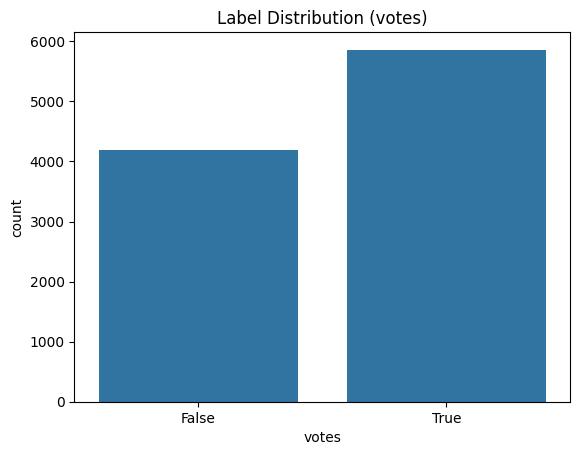

votes
True     5861
False    4194
Name: count, dtype: int64

In [3]:
# Label distribution
sns.countplot(x='votes', data=df)
plt.title('Label Distribution (votes)')
plt.show()
df['votes'].value_counts()

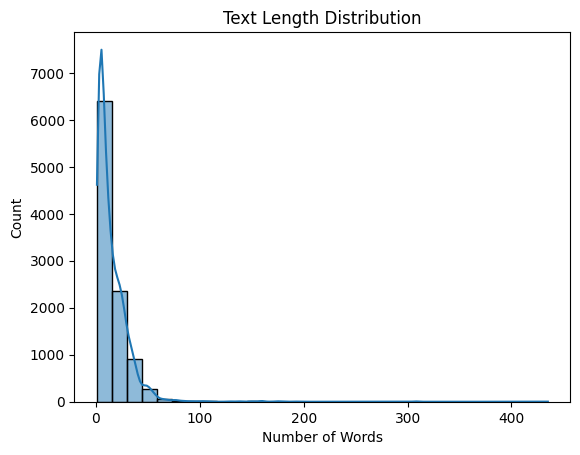

,count,mean,std,min,25%,50%,75%,max
votes,,,,,,,,
False,4194.0,7.755842,13.789809,1.0,3.0,5.0,8.0,435.0
True,5861.0,20.641188,16.942809,1.0,10.0,18.0,27.0,308.0


In [4]:
# Text length analysis
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
sns.histplot(df['text_length'], bins=30, kde=True)
plt.title('Text Length Distribution')
plt.xlabel('Number of Words')
plt.show()
df.groupby('votes')['text_length'].describe()

In [5]:
# Word frequency analysis for each label
from collections import Counter
def get_top_words(texts, n=20):
    words = ' '.join(texts).lower().split()
    return Counter(words).most_common(n)
print('Top words for votes=True:')
print(get_top_words(df[df['votes']==True]['text']))
print('Top words for votes=False:')
print(get_top_words(df[df['votes']==False]['text']))

Top words for votes=True:
[('di', 4677), ('main', 1994), ('s1tus', 1363), ('nya', 1295), ('ini', 1192), ('banget', 1185), ('yang', 1175), ('situs', 1108), ('aja', 1019), ('dan', 988), ('nih', 824), (',', 822), ('baru', 793), ('kasih', 744), ('udah', 726), ('bisa', 690), ('bagus', 685), ('𝐏𝐔𝐓𝐑𝐈𝐒𝐏𝐈𝐍', 677), ('link', 665), ('gua', 648)]
Top words for votes=False:
[('bang', 633), ('di', 463), ('ada', 378), ('nya', 339), ('yg', 331), ('ini', 290), ('saya', 270), ('bisa', 263), ('yang', 247), ('aja', 221), ('itu', 218), ('mau', 196), ('gak', 172), ('dan', 171), ('bg', 167), ('ga', 156), ('udah', 152), ('aku', 149), ('id', 149), ('dari', 139)]


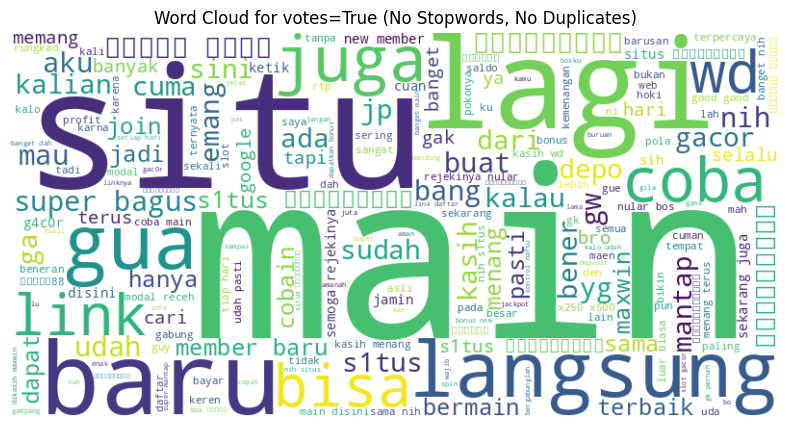

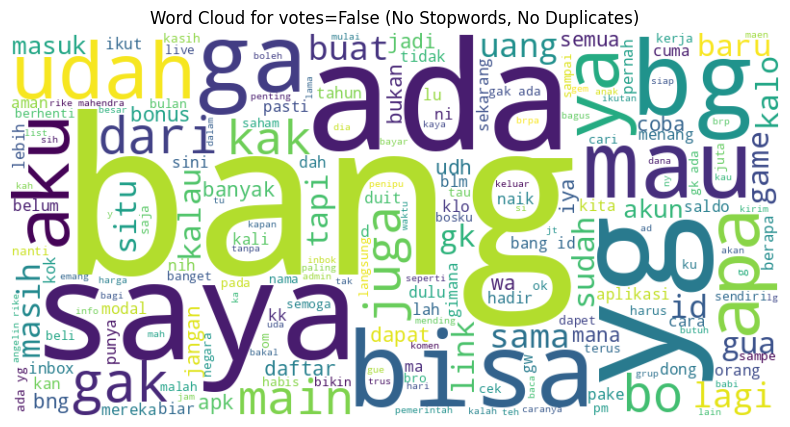

In [4]:
# Word cloud for each label (excluding stopwords and removing duplicates)
from wordcloud import STOPWORDS
custom_stopwords = set(STOPWORDS)
# Optionally add more stopwords relevant to your context
custom_stopwords.update(['yang', 'dan', 'di', 'ke', 'untuk', 'dengan', 'atau', 'ini', 'itu', 'nya', 'aja'])
import string
def preprocess_text(text):
    # Lowercase, remove punctuation, split, remove duplicates, join back
    words = str(text).lower().translate(str.maketrans('', '', string.punctuation)).split()
    unique_words = list(dict.fromkeys(words))
    return ' '.join(unique_words)
for label in [True, False]:
    texts = df[df['votes']==label]['text'].dropna().astype(str).apply(preprocess_text)
    all_text = ' '.join(texts)
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=custom_stopwords).generate(all_text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for votes={label} (No Stopwords, No Duplicates)')
    plt.show()

Texts containing 'bonus': 479
Texts containing 'petir': 110
Texts containing 'link': 885
Texts containing 'daftar': 363
Texts containing URLs: 1081


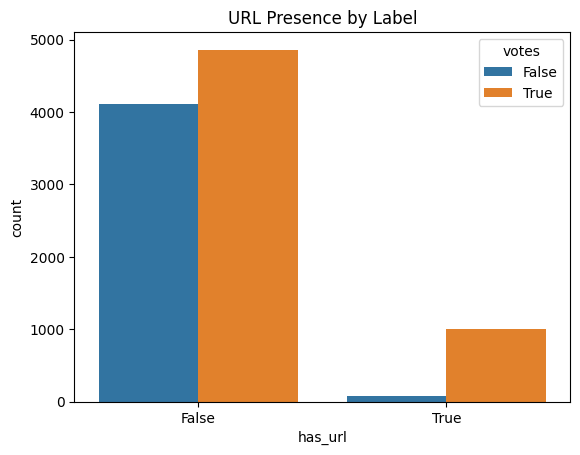

In [5]:
# Keyword and URL analysis
keywords = ['bonus', 'petir', 'link', 'daftar']
for kw in keywords:
    df[f'has_{kw}'] = df['text'].str.contains(kw, case=False, na=False)
    print(f"Texts containing '{kw}':", df[f'has_{kw}'].sum())
# URL presence
df['has_url'] = df['text'].str.contains(r'http[s]?://', na=False)
print('Texts containing URLs:', df['has_url'].sum())
sns.countplot(x='has_url', hue='votes', data=df)
plt.title('URL Presence by Label')
plt.show()

In [ ]:
# (Optional) Sentiment analysis if you have a sentiment library installed
# Example using textblob (pip install textblob)
try:
    from textblob import TextBlob
    df['sentiment'] = df['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
    sns.histplot(df['sentiment'], bins=30, kde=True)
    plt.title('Sentiment Distribution')
    plt.show()
    print(df.groupby('votes')['sentiment'].describe())
except ImportError:
    print('TextBlob not installed. Sentiment analysis skipped.')